# 3D Brain Tumor Segmentation — BraTS-PEDs

This notebook trains a **3D U-Net with two heads**: one segments the tumor from MRI scans, the other regresses the patient's **overall survival in days**.

**Project structure** (all complex logic lives in Python scripts):

| Module | Purpose |
|--------|---------|
| `brain_tumor_seg/config.py` | Paths and hyperparameters |
| `brain_tumor_seg/data/` | Dataset, DataLoaders & survival labels |
| `brain_tumor_seg/models/` | 3D U-Net + survival head |
| `brain_tumor_seg/visualization/` | Slice viewer, 3D scene & survival plots |
| `brain_tumor_seg/training/` | Training loop (combined loss) |
| `brain_tumor_seg/evaluation/` | Metrics & performance plots |

Each section below maps to one of those modules. The notebook only calls functions — no complex code here.

## 1. Setup & Configuration

Import the project modules and set the device (GPU if available).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add project root so we can import brain_tumor_seg
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Drop cached project modules so edits to brain_tumor_seg take effect when this
# cell is re-run, instead of silently using the versions already imported.
for _module in [m for m in list(sys.modules) if m.startswith("brain_tumor_seg")]:
    del sys.modules[_module]

import torch
from brain_tumor_seg.config import (
    TRAIN_DIR, VAL_DIR, BATCH_SIZE, NUM_EPOCHS,
    LEARNING_RATE, TARGET_SHAPE, SEED, CHECKPOINT_DIR,
)
from brain_tumor_seg.utils.helpers import set_seed

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Training data: {TRAIN_DIR}")
print(f"Validation data: {VAL_DIR}")

Device: cpu
Training data: C:\Users\PC\OneDrive\Desktop\Brain Cancer Segmentation\PKG - BraTS-PEDs-v1\BraTS-PEDs-v1\Training
Validation data: C:\Users\PC\OneDrive\Desktop\Brain Cancer Segmentation\PKG - BraTS-PEDs-v1\BraTS-PEDs-v1\Validation


## 2. DataLoader

Create DataLoaders for **training** and **validation**.

> **Note:** The official Validation folder has no segmentation masks, so validation metrics (Dice, loss) are computed on a held-out split from the Training folder. A separate inference loader loads the Validation folder for prediction on unseen cases.

Survival targets are attached here too. Each sample carries a `has_survival` flag, because only part of the cohort is labelled — see section 3C. The target scale is fitted on the **training split alone**, so the held-out cases cannot leak their label distribution into the normalisation.

In [2]:
from brain_tumor_seg.data import (
    create_train_dataloader,
    create_val_dataloader,
    load_survival_stats,
)

train_loader, val_loader = create_train_dataloader(
    train_dir=TRAIN_DIR,
    batch_size=BATCH_SIZE,
)

inference_loader = create_val_dataloader(
    val_dir=VAL_DIR,
    batch_size=BATCH_SIZE,
)

# Fitted on the training split and saved next to the checkpoints. Needed to turn
# the survival head's normalised output back into days.
survival_stats = load_survival_stats()
print(f"Survival target scale: {survival_stats}")

Training cases:   219
Validation cases: 38
Survival labels:  101 train / 14 val (of 115 in the metadata)
Inference cases (Validation folder): 91
Survival target scale: SurvivalStats(mean=6.025243346849058, std=0.9038941178973985, count=101)


## 3. Visualizer

Browse a sample MRI volume in **three views** (axial, coronal, sagittal) using the interactive slice slider.

Red overlay = tumor mask (ground truth).

In [3]:
from brain_tumor_seg.visualization import show_volume_with_slider

# Load one sample from the training set
sample = train_loader.dataset[0]
image = sample["image"]   # shape: (4, D, H, W) — 4 MRI modalities
mask = sample["mask"]     # shape: (1, D, H, W) — binary tumor mask
case_id = sample["case_id"]

show_volume_with_slider(
    image=image,
    mask=mask,
    title=f"Case: {case_id}",
)

interactive(children=(IntSlider(value=48, continuous_update=False, description='Axial', max=95), IntSlider(val…

## 3B. 3D View

The same case as a rotatable **3D scene** instead of flat slices, stripped down to the anatomy alone:

- A **semi-transparent grey brain surface**, taken as an isosurface of the MRI intensity, so you can see inside the head.
- Each **tumor component as a solid coloured mesh**, one colour per connected mass, so a mask made of several separate pieces is easy to tell apart from a single blob.

Nothing else: no tick numbers, no gridlines, no axis panes or bounding box, no legend — just the head shell and the tumor on white.

**How to interact.** The mode bar sits at the top-right of the scene:

| Gesture | Does |
|---------|------|
| **left-drag** | rotate (turntable) |
| **scroll wheel** | zoom in / out |
| **right-drag**, or **Ctrl + left-drag**, or the mode bar **Pan** button then left-drag | pan |
| **double-click** | reset the camera to the starting view |

`show_3d(fig)` is used instead of `fig.show()` because this environment's default Plotly renderer is `browser`, which opens the scene in a separate tab instead of drawing it in the output cell.

**To bring the axes and legend back**, pass `clean=False` (restores the anatomically labelled `L-R` / `A-P` / `S-I` axes with their ticks, grid and panes) and `show_legend=True` (legend entries also let you click a surface to hide it).

In [4]:
from brain_tumor_seg.visualization import show_volume_3d, show_3d, save_figure_html

# Reuses image, mask and case_id loaded in the visualizer cell above.
# min_voxels=10 drops the stray specks this case produces: the mask is resized
# 240**3 -> 96**3 by trilinear interpolation and then re-thresholded, which
# scatters one- and two-voxel fragments that would each become their own mesh.
fig_3d = show_volume_3d(image, mask, min_voxels=10, title=f"Case: {case_id}")

# show_3d, not fig.show(): renders inline in Cursor/VS Code with wheel zoom and
# the mode bar on. Add clean=False, show_legend=True above for labelled axes.
show_3d(fig_3d)

# To view it outside the notebook, write a standalone HTML file — it keeps the
# same rotate/zoom/pan behaviour:
# save_figure_html(fig_3d, "brain_3d_view.html")

## 3C. Survival Rate

The same patient's **overall survival**, and where it sits among the rest of the cohort. The label comes from the metadata TSV next to the case folders; only two of its columns are used, `BraTS-SubjectID` and `Overall survival (days)`.

**Coverage is the thing to keep in mind here.** The TSV has 457 rows, but only **115** carry a usable survival value (one further row says `Not Reported`, which is treated as missing). Every one of those 115 IDs matches a case in the **Training** folder and **none** match the official Validation folder — so survival can be *predicted* for a Validation case, but never *scored* against a ground truth.

That means roughly **45% of the 257 training cases are labelled**. The unlabelled ones are deliberately **not** dropped: they still train the segmentation head and are simply masked out of the survival loss. Dropping them would throw away more than half the segmentation data to gain a sparse second task.

Survival is drawn on a **log axis** because the labels run from 10 days to 5,274 days; on a linear axis the handful of multi-year survivors squash everything else into the leftmost bin. For the same reason the model regresses `log1p(days)` rather than raw days, and errors are converted back into days before they are reported.

Labeled cases in metadata : 115
Labeled in this folder    : 115 of 257 (45%)
Survival range            : 10 days (0.0 years)  to  5,274 days (14.4 years)
Median / mean             : 397 / 641 days

BraTS-PED-00016-000: 478 days (1.3 years) — 60th percentile of 115 labeled cases


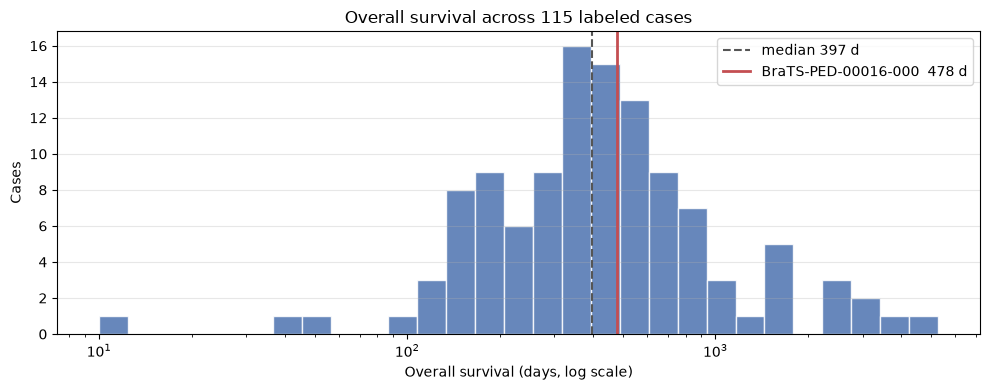

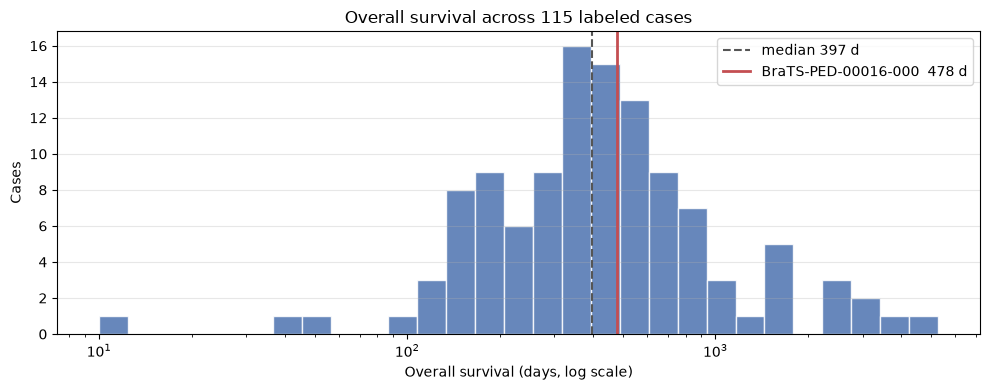

In [5]:
from brain_tumor_seg.data import BraTSDataset, load_survival_days
from brain_tumor_seg.visualization import plot_survival_distribution, print_survival_report

survival_days = load_survival_days()

# case_id is the same case shown in the slice viewer and the 3D scene above, so
# the red line below marks the patient currently on screen.
print_survival_report(
    survival_days,
    case_ids=BraTSDataset(TRAIN_DIR).case_ids,
    highlight_case=case_id,
)

plot_survival_distribution(survival_days, highlight_case=case_id)

## 4. Model

Create the dual-head 3D U-Net. It takes 4 MRI channels and returns **both** outputs at once:

| Head | Output | Reads from |
|------|--------|------------|
| Segmentation | tumor probability map, `(1, D, H, W)` | full decoder with skip connections |
| Survival | one number per patient | **the tumor only** — encoder features pooled inside the mask, plus log tumor volume |

The survival head never sees the rest of the brain. During training it is given the **ground-truth mask**, so it learns “given this mass, how long did the patient live?”. At inference the **predicted tumor** is used instead. The mask is detached, so the survival loss cannot warp the segmentation to fit the survival target.

It predicts on the normalised `log1p(days)` scale; `SurvivalStats.to_days()` converts back.

`MultiTaskUNet3D` *composes* an unmodified `UNet3D` rather than subclassing it, so the segmentation weights stay layout-compatible with the single-head checkpoints from earlier runs — which is what the warm start below relies on.

In [6]:
from brain_tumor_seg.models import MultiTaskUNet3D

model = MultiTaskUNet3D(in_channels=4, out_channels=1)
model = model.to(device)

# Optional warm start. This file is a copy of the checkpoint from the earlier
# segmentation-only run, so the encoder/decoder begin already trained and only
# the survival head starts from scratch. Delete the file to train from scratch.
warm_start = CHECKPOINT_DIR / "best_model_segmentation_only.pth"
if warm_start.is_file():
    model.load_segmentation_weights(warm_start)
    print(f"Warm-started segmentation weights from {warm_start.name}")

seg_params = sum(p.numel() for p in model.segmentation.parameters())
surv_params = sum(p.numel() for p in model.survival_head.parameters())
print(f"Segmentation parameters: {seg_params:,}")
print(f"Survival head parameters: {surv_params:,}")
print(f"Total parameters: {seg_params + surv_params:,}")

Warm-started segmentation weights from best_model_segmentation_only.pth
Segmentation parameters: 1,402,561
Survival head parameters: 8,385
Total parameters: 1,410,946


## 5. Training Loop

Train for the configured number of epochs. Checkpoints are saved automatically whenever validation Dice improves.

The optimiser minimises **one combined loss**:

```
BCE + Dice                          (segmentation, every case)
  + SURVIVAL_LOSS_WEIGHT * Huber    (survival, labelled cases only)
```

The survival term is computed from **tumor-local** features: the ground-truth mask is passed in so the head pools only inside the mass. Unlabelled cases still contribute exactly zero to that term (via `has_survival`) while training the segmentation head as usual.

`SURVIVAL_LOSS_WEIGHT` defaults to `0.3` so segmentation stays the primary task. The survival term uses **Huber** rather than squared error, so the single 5,274-day case cannot drag the head around.

With `BATCH_SIZE = 1` most batches contain no survival label at all, so the head only receives a gradient on roughly 101 of the ~219 steps in an epoch. That is correct, just slow — a larger batch size would give it a steadier signal if memory allows.

> **Note:** Best-model selection still tracks **validation Dice only**. `val_surv_mae_days` is computed over just 14 labelled held-out cases, which is far too few to select on — read it as a trend, not a number.

In [7]:
from brain_tumor_seg.training import Trainer

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    learning_rate=LEARNING_RATE,
    checkpoint_dir=CHECKPOINT_DIR,
)

history = trainer.train(num_epochs=NUM_EPOCHS)

Epoch 1/20 train:   0%|          | 0/219 [00:00<?, ?it/s]

Epoch 1/20 val:   0%|          | 0/38 [00:00<?, ?it/s]


Epoch 1/20  -  16m 52s
----------------------------------------
  Train Loss : 0.5933
  Val Loss   : 0.5567
  Val Dice   : 0.8312
  Surv Train : 0.1906
  Surv Val   : 0.1671
  Surv MAE   : 551 days (median 176, 14 labeled)
  Elapsed    : 16m 52s  (ETA 5h 20m 25s)
  >> Saved best model (Dice=0.8312)


Epoch 2/20 train:   0%|          | 0/219 [00:00<?, ?it/s]

Epoch 2/20 val:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 19/20 val:   0%|          | 0/38 [00:00<?, ?it/s]


Epoch 19/20  -  16m 50s
----------------------------------------
  Train Loss : 0.1195
  Val Loss   : 0.2443
  Val Dice   : 0.8413
  Surv Train : 0.0320
  Surv Val   : 0.1795
  Surv MAE   : 578 days (median 252, 14 labeled)
  Elapsed    : 5h 51m 58s  (ETA 18m 31s)


Epoch 20/20 train:   0%|          | 0/219 [00:00<?, ?it/s]

Epoch 20/20 val:   0%|          | 0/38 [00:00<?, ?it/s]


Epoch 20/20  -  16m 43s
----------------------------------------
  Train Loss : 0.1131
  Val Loss   : 0.2477
  Val Dice   : 0.8347
  Surv Train : 0.0326
  Surv Val   : 0.1722
  Surv MAE   : 574 days (median 227, 14 labeled)
  Elapsed    : 6h 08m 41s

Training finished in 6h 08m 41s


## 6. Evaluation

Plot **loss** and **Dice** curves over training epochs, plus two extra panels for the survival head: its Huber loss, and its validation error expressed **in days** rather than on the normalised scale nobody can judge by eye.

Plot saved to C:\Users\PC\OneDrive\Desktop\Brain Cancer Segmentation\Abuya Code\outputs\plots\training_history.png


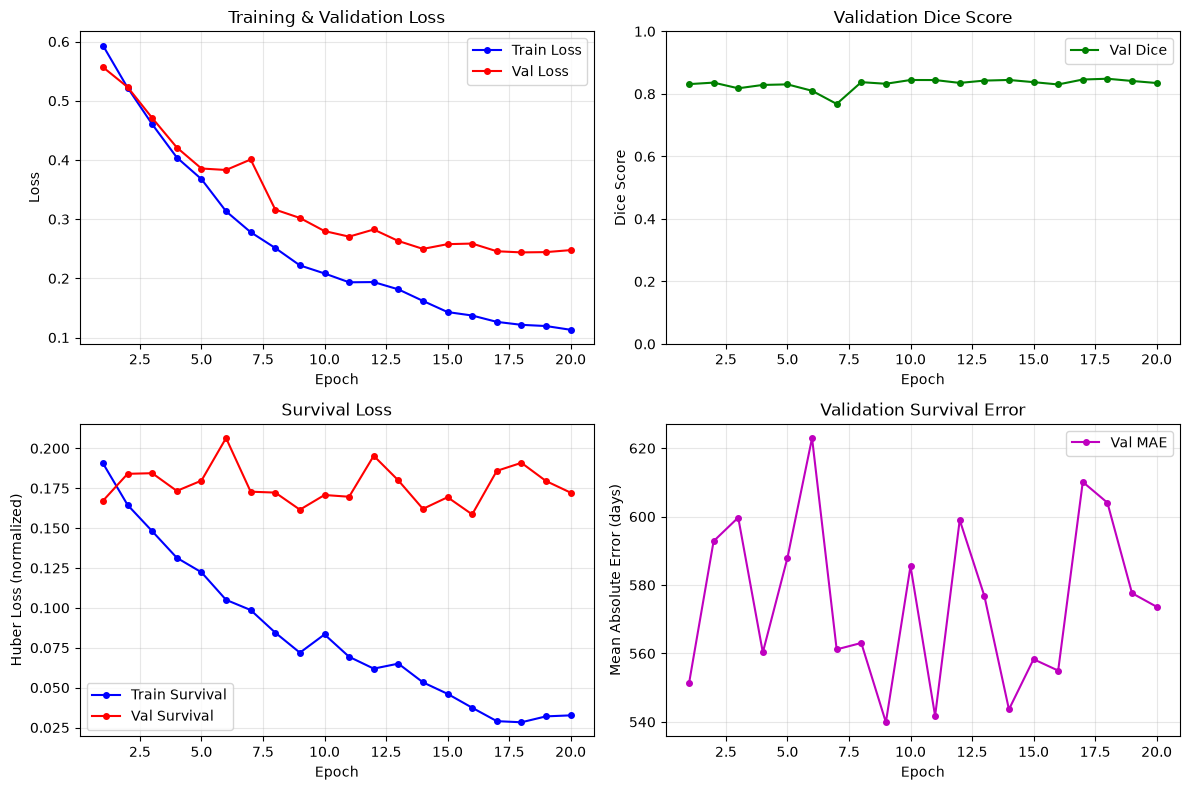

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Final Val Loss: 0.1960
Final Val Dice: 0.8347
Final Val Survival MAE: 574 days (median 227, over 14 labelled cases)


In [8]:
from brain_tumor_seg.evaluation import plot_training_history, evaluate_model

plot_training_history(history)

metrics = evaluate_model(model, val_loader, device, survival_stats=survival_stats)
print(f"Final Val Loss: {metrics['loss']:.4f}")
print(f"Final Val Dice: {metrics['dice']:.4f}")

# Present only when the survival head ran against labelled validation cases.
if "surv_mae_days" in metrics:
    print(
        f"Final Val Survival MAE: {metrics['surv_mae_days']:,.0f} days "
        f"(median {metrics['surv_median_ae_days']:,.0f}, "
        f"over {int(metrics['surv_count'])} labelled cases)"
    )

## 7. Inference & Visualization (Optional)

Load the best saved model and run **both heads** on a Validation case: the predicted tumor mask goes to the slice slider, and the predicted survival is printed in days.

> The official Validation cases have **no** ground-truth mask and **no** survival label, so nothing here can be scored — these are predictions on genuinely unseen data.

In [9]:
from brain_tumor_seg.evaluation import predict_volume, predict_survival_days
from brain_tumor_seg.visualization import show_volume_with_slider, format_survival

# Load best checkpoint
trainer.load_checkpoint("best_model.pth")

# Get one case from the Validation folder (no ground-truth mask)
inf_sample = inference_loader.dataset[0]
inf_image = inf_sample["image"]
inf_case_id = inf_sample["case_id"]

# Predict tumor mask
predicted_mask = predict_volume(model, inf_image, device)

# Predict survival from the same forward features. Nothing to compare it
# against: no Validation case carries a survival label.
if survival_stats is not None:
    predicted_days = predict_survival_days(model, inf_image, device, survival_stats)
    print(f"Predicted survival for {inf_case_id}: {format_survival(predicted_days)}")

show_volume_with_slider(
    image=inf_image,
    mask=predicted_mask,
    title=f"Prediction — Case: {inf_case_id}",
)

Predicted survival for BraTS-PED-00267-000: 612 days (1.7 years)


interactive(children=(IntSlider(value=48, continuous_update=False, description='Axial', max=95), IntSlider(val…

### 7b. 3D Prediction View

The prediction from the cell above in the same **3D scene** as section 3B: translucent head shell, predicted tumor solid inside it, no axes or legend.

`min_voxels` matters more here than for ground truth. A thresholded model output is speckled with **spurious one- and two-voxel islands**, and every island would otherwise be drawn as its own coloured mesh, so the view fills up with confetti. Lower the value to inspect everything the model actually predicted.

Same gestures as above: left-drag rotates, scroll wheel zooms, right-drag (or `Ctrl` + left-drag, or the mode bar **Pan** button) pans, double-click resets the camera.

In [10]:
from brain_tumor_seg.visualization import show_volume_3d, show_3d

# Reuses inf_image, predicted_mask and inf_case_id from the inference cell above.
# min_voxels=25 is deliberately stricter than the ground-truth view: predictions
# scatter far more spurious islands than a resized mask does.
fig_pred_3d = show_volume_3d(
    inf_image,
    predicted_mask,
    min_voxels=25,
    title=f"3D Prediction — Case: {inf_case_id}",
)

show_3d(fig_pred_3d)